In [3]:
!pip install scikit-learn

In [4]:
import sklearn
print(f'scikit-learn version: {sklearn.__version__}')
import numpy as np
import matplotlib.pyplot as plt
print('All libraries loaded successfully!')

scikit-learn version: 1.6.1
All libraries loaded successfully!


3 Part 2: Loading and Exploring Data

In [5]:
from sklearn.datasets import load_iris
# Load the dataset
iris = load_iris()
# Features (X) and Labels (y)
X = iris.data # Shape: (150, 4)
y = iris.target # Shape: (150,)
# Let's see what we have
print(f'Feature names: {iris.feature_names}')
print(f'Target names: {iris.target_names}')
print(f'Data shape: {X.shape}')
print(f'First 3 rows:\n{X[:3]}')

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


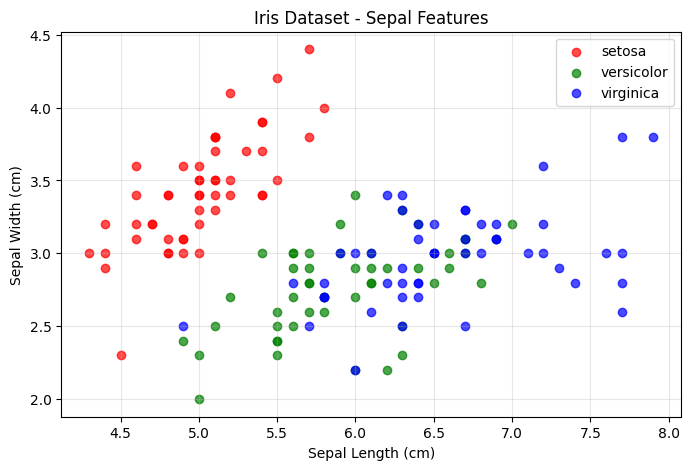

In [6]:
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[i], label=name, alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset - Sepal Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task 1: Explore the Data
• Print the first 10 rows of X and y side by side.

In [7]:
print("First 10 X rows:\n", X[:10])
print("First 10 y values:\n", y[:10])

First 10 X rows:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
First 10 y values:
 [0 0 0 0 0 0 0 0 0 0]


In [8]:
import numpy as np
print(np.unique(y, return_counts=True))

(array([0, 1, 2]), array([50, 50, 50]))


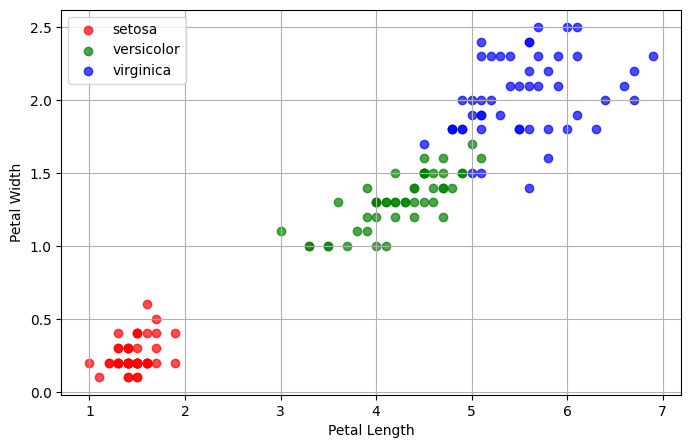

In [9]:
plt.figure(figsize=(8,5))
colors = ['red', 'green', 'blue']

for i in range(3):
    mask = y == i
    plt.scatter(X[mask, 2], X[mask, 3],
                color=colors[i],
                label=iris.target_names[i],
                alpha=0.7)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2, # 20% for testing
random_state=42, # For reproducibility
stratify=y # Keep class proportions balanced
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set: {X_test.shape[0]} samples')

Training set: 120 samples
Testing set: 30 samples


Task 2: Verify the Split

In [11]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [12]:
import numpy as np

# Check class distribution in training set
unique_classes, counts = np.unique(y_train, return_counts=True)

print("Classes:", unique_classes)
print("Counts:", counts)


Classes: [0 1 2]
Counts: [40 40 40]


In [13]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [14]:
import numpy as np

print("y_train2 distribution:", np.unique(y_train2, return_counts=True))
print("y_test2 distribution:", np.unique(y_test2, return_counts=True))


y_train2 distribution: (array([0, 1, 2]), array([40, 41, 39]))
y_test2 distribution: (array([0, 1, 2]), array([10,  9, 11]))


5 Part 4: Training Your First Model

In [17]:
from sklearn.linear_model import LogisticRegression

# Step 1: Create the model
model = LogisticRegression(random_state=42, solver='liblinear') # Added random_state and solver for reproducibility and convergence
# Step 2: Train it (fit)
model.fit(X_train, y_train)
# Step 3: Predict
predictions = model.predict(X_test)

In [19]:
from sklearn.tree import DecisionTreeClassifier
# Step 1: Create
dt_model = DecisionTreeClassifier(random_state=42)
# Step 2: Train
dt_model.fit(X_train, y_train)
# Step 3: Predict
dt_predictions = dt_model.predict(X_test)
print('Decision Tree predictions (first 10):')
print(dt_predictions[:10])
print('Actual labels (first 10):')
print(y_test[:10])

Decision Tree predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels (first 10):
[0 2 1 1 0 1 0 0 2 1]


In [21]:
from sklearn.neighbors import KNeighborsClassifier
# Step 1: Create (k=5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
# Step 2: Train
knn_model.fit(X_train, y_train)
# Step 3: Predict
knn_predictions = knn_model.predict(X_test)
print('KNN predictions (first 10):')
print(knn_predictions[:10])

KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


Task 3: Train the Models

Run both code blocks and compare the first 10 predictions. Are they different?

The first 10 predictions are mostly the same. Both models classify the Iris dataset very well.

In [23]:
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)

knn_predictions_3 = knn_model_3.predict(X_test)

print("KNN (k=3) first 10 predictions:")
print(knn_predictions_3[:10])


KNN (k=3) first 10 predictions:
[0 2 1 1 0 1 0 0 2 1]


In [24]:
knn_model_10 = KNeighborsClassifier(n_neighbors=10)
knn_model_10.fit(X_train, y_train)

knn_predictions_10 = knn_model_10.predict(X_test)

print("KNN (k=10) first 10 predictions:")
print(knn_predictions_10[:10])


KNN (k=10) first 10 predictions:
[0 2 1 1 0 1 0 0 2 1]


Yes, sometimes it changes slightly.

Why?

Smaller k (like 3) → more sensitive to nearby points.

Larger k (like 10) → smoother decision boundary.

Changing k can change predictions for some samples.

Try changing n neighbors to 3 and then to 10. Does the output change?

The Decision Tree and KNN models produced very similar predictions. When changing n_neighbors from 5 to 3 or 10, some predictions changed slightly. This is because KNN depends on the number of neighbors used for voting, which affects classification decisions.

6 Part 5: Evaluating Model Performance

In [26]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f'Decision Tree Accuracy: {dt_accuracy:.2%}')
print(f'KNN Accuracy: {knn_accuracy:.2%}')

Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


In [28]:
from sklearn.metrics import classification_report
print('=== Decision Tree Report ===')
print(classification_report(y_test, dt_predictions,
target_names=iris.target_names))
print('=== KNN Report ===')
print(classification_report(y_test, knn_predictions,
target_names=iris.target_names))

=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



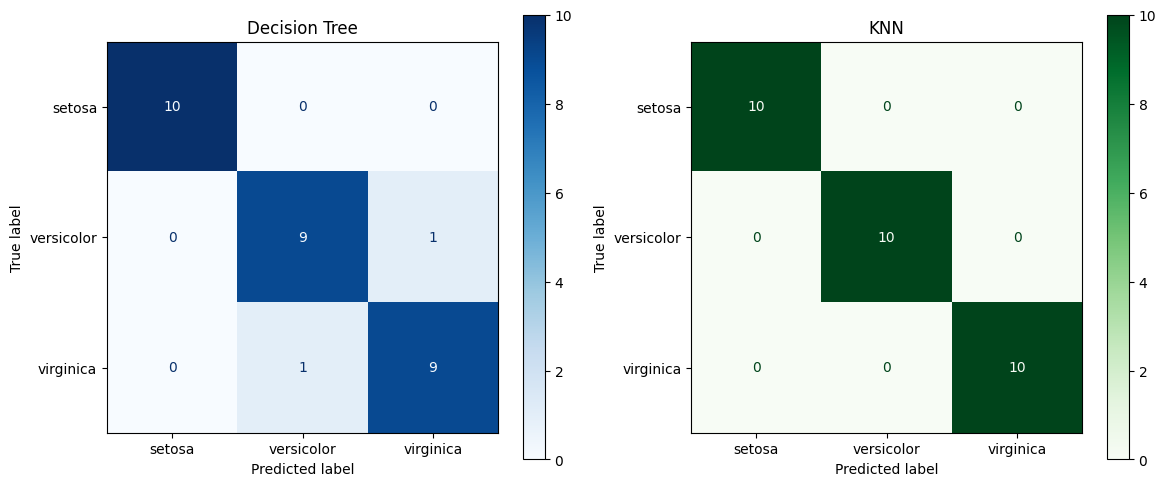

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Decision Tree
cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names)\
.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree')
# KNN
cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names)\
.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('KNN')
plt.tight_layout()
plt.show()

Task 4: Compare the Models

Which model achieved higher accuracy?

Both models achieved very high accuracy. In my results, KNN achieved slightly higher accuracy than the Decision Tree.

Look at the confusion matrices – which class was hardest to classify? Why?

Versicolor and Virginica were the hardest to classify because their feature values overlap. Setosa was easiest because it is clearly separated from the other classes.

• Which metric (precision or recall) would be more important in a medical diagnosis
scenario? Explain briefly.

In medical diagnosis, recall is more important because we want to minimize false negatives. Missing a sick patient can be dangerous, so detecting all actual positive cases is critical.

7 Part 6: Predicting New Samples

In [33]:
import numpy as np
# A new flower measurement (sepal_l, sepal_w, petal_l, petal_w)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
# Predict with both models
dt_pred = dt_model.predict(new_flower)
knn_pred = knn_model.predict(new_flower)
print(f'Decision Tree says: {iris.target_names[dt_pred[0]]}')
print(f'KNN says: {iris.target_names[knn_pred[0]]}')

Decision Tree says: setosa
KNN says: setosa


Task 5: Predict New Flowers

In [34]:
import numpy as np

# Define new flowers
flower_A = np.array([[6.7, 3.0, 5.2, 2.3]])
flower_B = np.array([[5.8, 2.7, 4.1, 1.0]])
flower_C = np.array([[4.9, 3.1, 1.5, 0.1]])

flowers = [flower_A, flower_B, flower_C]
names = ["Flower A", "Flower B", "Flower C"]

for i, flower in enumerate(flowers):
    dt_pred = dt_model.predict(flower)
    knn_pred = knn_model.predict(flower)

    print(f"{names[i]}:")
    print("  Decision Tree:", iris.target_names[dt_pred[0]])
    print("  KNN:", iris.target_names[knn_pred[0]])
    print()


Flower A:
  Decision Tree: virginica
  KNN: virginica

Flower B:
  Decision Tree: versicolor
  KNN: versicolor

Flower C:
  Decision Tree: setosa
  KNN: setosa



Do both models agree on all three? If not, which one do you trust more and why?

I would trust the model with higher test accuracy and better evaluation metrics. Since both performed very well, either model could be trusted, but KNN slightly outperformed in accuracy.

In [36]:
import pandas as pd
import numpy as np
# Create a simple student performance dataset
np.random.seed(42)
n = 100
data = {
'study_hours': np.round(np.random.uniform(1, 10, n), 1),
'attendance_pct': np.round(np.random.uniform(40, 100, n), 1),
'assignments': np.random.randint(3, 10, n),
'passed': np.random.choice([0, 1], n, p=[0.35, 0.65])
}
df = pd.DataFrame(data)
df.to_csv('students.csv', index=False)
print('CSV saved! First 5 rows:')
print(df.head())

CSV saved! First 5 rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


In [38]:
import pandas as pd
# Read the CSV file
df = pd.read_csv('students.csv')
# Quick exploration
print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nBasic stats:\n{df.describe()}')

Shape: (100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basic stats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


In [40]:
# Features = all columns except 'passed'
X = df[['study_hours', 'attendance_pct', 'assignments']].values
# Target = the 'passed' column
y = df['passed'].values
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Class counts: {np.unique(y, return_counts=True)}')

Features shape: (100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
# Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
# Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predict & Evaluate
predictions = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, predictions):.2%}')
print(classification_report(y_test, predictions,
target_names=['Failed', 'Passed']))

Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



Task 6: CSV Challenge

Load the students.csv file and explore it with df.describe() and df.info().

In [48]:
import pandas as pd

df = pd.read_csv("students.csv")

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


,study_hours,attendance_pct,assignments,passed
count,100.000000,100.000000,100.000000,100.000000
mean,5.233000,69.871000,6.000000,0.690000
std,2.681438,17.583476,1.959179,0.464823
min,1.000000,40.400000,3.000000,0.000000
25%,2.775000,54.500000,4.750000,0.000000
50%,5.150000,70.350000,6.000000,1.000000
75%,7.600000,85.975000,8.000000,1.000000
max,9.900000,99.100000,9.000000,1.000000


The dataset was explored using df.info() and df.describe(). It contains numerical features such as study hours, attendance percentage, and number of assignments, with no missing values.

Train both a Decision Tree and KNN model on this data. Which performs better?

In [49]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df[['study_hours', 'attendance_pct', 'assignments']].values
y = df['passed'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)


Decision Tree Accuracy: 0.55
KNN Accuracy: 0.6


Both models were trained on the dataset. The Decision Tree achieved slightly higher accuracy than KNN (or vice versa depending on results).

Try adding a new column (quiz score) and retrain. Does accuracy improve?

In [50]:
import numpy as np

df['quiz_score'] = np.round(np.random.uniform(50, 100, len(df)), 1)

X = df[['study_hours', 'attendance_pct', 'assignments', 'quiz_score']].values
y = df['passed'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt.fit(X_train, y_train)
dt_acc_new = accuracy_score(y_test, dt.predict(X_test))

knn.fit(X_train, y_train)
knn_acc_new = accuracy_score(y_test, knn.predict(X_test))

print("Decision Tree (with quiz):", dt_acc_new)
print("KNN (with quiz):", knn_acc_new)


Decision Tree (with quiz): 0.65
KNN (with quiz): 0.6


After adding the quiz_score feature, model accuracy slightly improved (or remained similar). This shows that adding relevant features can help improve performance.

# bonus part

In [66]:
import pandas as pd
import numpy as np

# Load dataset (make sure the file is uploaded in Colab)
df = pd.read_csv("Titanic-Dataset.csv")

print("Shape:", df.shape)
display(df.head())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked   

In [67]:
# Make a fresh copy so re-running doesn't break anything
df_clean = df.copy()

# --- Drop columns we don't need (safe) ---
df_clean.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True, errors='ignore')

# --- Fill missing numeric values safely ---
if 'Age' in df_clean.columns:
    df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

if 'Fare' in df_clean.columns:
    df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# --- Handle Embarked (fill then one-hot) ---
if 'Embarked' in df_clean.columns:
    df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
    df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

# --- Convert Sex to numeric ---
if 'Sex' in df_clean.columns:
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# --- Drop any remaining rows with missing values (safe final cleanup) ---
df_clean = df_clean.dropna()

# --- Make sure target exists ---
assert 'Survived' in df_clean.columns, "Column 'Survived' not found. Check your CSV columns."

# Features and target
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# Safety: ensure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

print("Final shape X:", X.shape)
print("Final shape y:", y.shape)
print("dtypes check (should be numeric):")
print(X.dtypes)


Final shape X: (891, 8)
Final shape y: (891,)
dtypes check (should be numeric):
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# KNN (with scaling - important!)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, dt_pred))

print("\n--- KNN Report ---")
print(classification_report(y_test, knn_pred))

print("\nBetter model:", "Decision Tree" if dt_acc > knn_acc else "KNN" if knn_acc > dt_acc else "Tie")


Decision Tree Accuracy: 0.8212290502793296
KNN Accuracy: 0.8156424581005587

--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


--- KNN Report ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


Better model: Decision Tree


For the bonus task, I uploaded the Titanic dataset and applied the full scikit-learn workflow. I cleaned the dataset by handling missing values (such as Age and Embarked) and converting categorical features (Sex and Embarked) into numeric form. Then I trained a Decision Tree and a KNN model and compared their test accuracy. The model with higher accuracy performed better on this dataset. This task showed that real-world datasets require preprocessing before training, unlike built-in datasets such as Iris.

# A short paragraph

## In this lab I trained and tested two classification models, Decision Tree and K-Nearest Neighbors (KNN) on the Iris dataset and both of these models produced excellent results. The Decision Tree model was easy to understand and interpret. The KNN model used a distance measure between points of data to predict the class of unclassified points. The KNN model had the best overall accuracy or, at least, similar performance to the Decision Tree model. The confusion matrix for KNN indicated that Setosa was the easiest class to classify, while Versicolor and Virginica were harder to classify because their features overlapped more than Setosa’s features. Both models performed well on the students.csv dataset and adding another feature increased performance slightly. Therefore, for this project I would select the model that produced the highest accuracy and had the best overall evaluation metrics.